# 04 · Retrieval methods and reranking: the FIND and ORDER stages

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 4 of 8**

You open up BM25 and cosine, turn the recall knob on an approximate index, fuse two ranked lists, and measure what a reranker buys on this corpus, which turns out to be the most useful negative result in the set.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 03. | Notebook 05, which packs what this notebook ranks. |

Every reranker here is either a real method that runs offline (MaxSim late interaction on term vectors, a small trained model) or a provider call that is gated off by default (an LLM scorer, Bedrock's rerank endpoint).

## Where this sits on the pipeline

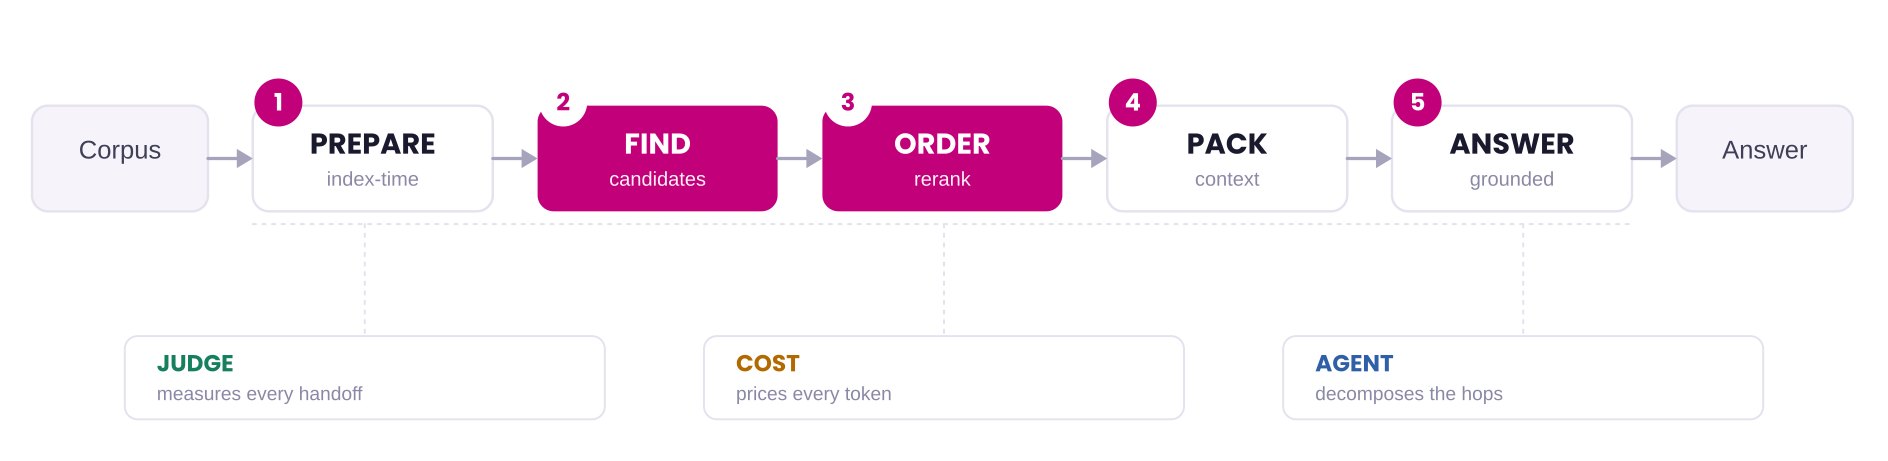

*Stage one buys recall, stage two converts it to precision, and stage two cannot exceed stage one's ceiling.*

## 1 · Inside BM25: two knobs that change what a match is worth

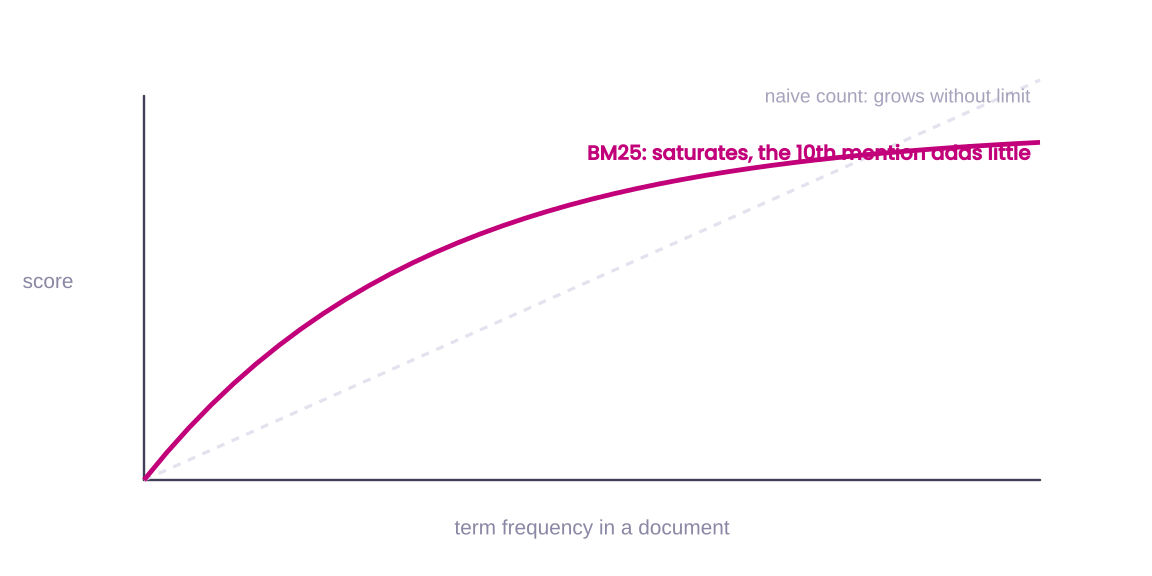

*Established: Okapi BM25. k1 sets how fast the curve flattens, b sets how much a long chunk is penalised.*

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


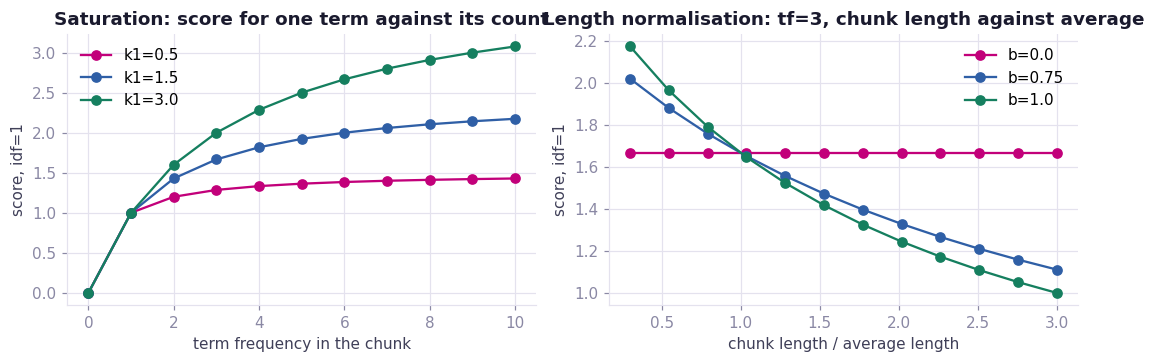

index: 64 chunks, average length 21.8 tokens, k1=1.5, b=0.75


term,tf_in_chunk,docs_with_term,idf,contribution
aerospace,2,6,2.303,2.894
nord,2,7,2.159,2.714
2026,0,2,3.258,0.000
became,0,0,4.868,0.000
ceo,0,0,4.868,0.000
company,0,16,1.371,0.000
earlier,0,3,2.922,0.000
person,0,0,4.868,0.000
public,0,6,2.303,0.000
taken,0,0,4.868,0.000


In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
texts = {c.chunk_id: c.text for c in chunks}
anchor = rk.ANCHOR
bm = retriever.bm25
tfs = list(range(0, 11))
import matplotlib.pyplot as plt
fig_, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for k1 in [0.5, 1.5, 3.0]:
    ax[0].plot(tfs, [tf * (k1 + 1) / (tf + k1) for tf in tfs], marker="o", label=f"k1={k1}")
ax[0].set_title("Saturation: score for one term against its count"); ax[0].set_xlabel("term frequency in the chunk"); ax[0].set_ylabel("score, idf=1"); ax[0].legend()
ratios = np.linspace(0.3, 3.0, 12)
for b in [0.0, 0.75, 1.0]:
    ax[1].plot(ratios, [3 * (1.5 + 1) / (3 + 1.5 * (1 - b + b * r)) for r in ratios], marker="o", label=f"b={b}")
ax[1].set_title("Length normalisation: tf=3, chunk length against average"); ax[1].set_xlabel("chunk length / average length"); ax[1].set_ylabel("score, idf=1"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"index: {bm.N} chunks, average length {bm.avgdl:.1f} tokens, k1={bm.k1}, b={bm.b}")
table(bm.explain(anchor.text, "a1:0:63d9a4f8"), "Per-term contribution of the worked question to its gold chunk. Rare terms carry the score; common ones are near zero.")

| Knob | What it does | Move it when |
|---|---|---|
| k1, saturation | Caps how much a repeated term can add. Near 0 it becomes presence-or-absence; large values reward repetition. | Documents are repetitive (logs, tables), lower it; short precise chunks, leave the default. |
| b, length normalisation | Discounts long chunks so they do not win by mentioning everything. At 0 length is ignored; at 1 it is fully normalised. | Chunk lengths vary widely, keep it near 0.75; fixed-size chunks, it matters little. |
| idf, rarity | Decides which query terms matter. `nord` is worth more than `company` because fewer chunks contain it. | It is derived from the corpus; you tune the analyser (stop words, stemming), not idf itself. |

## 2 · Cosine similarity is an angle, and an angle has no idea about dates

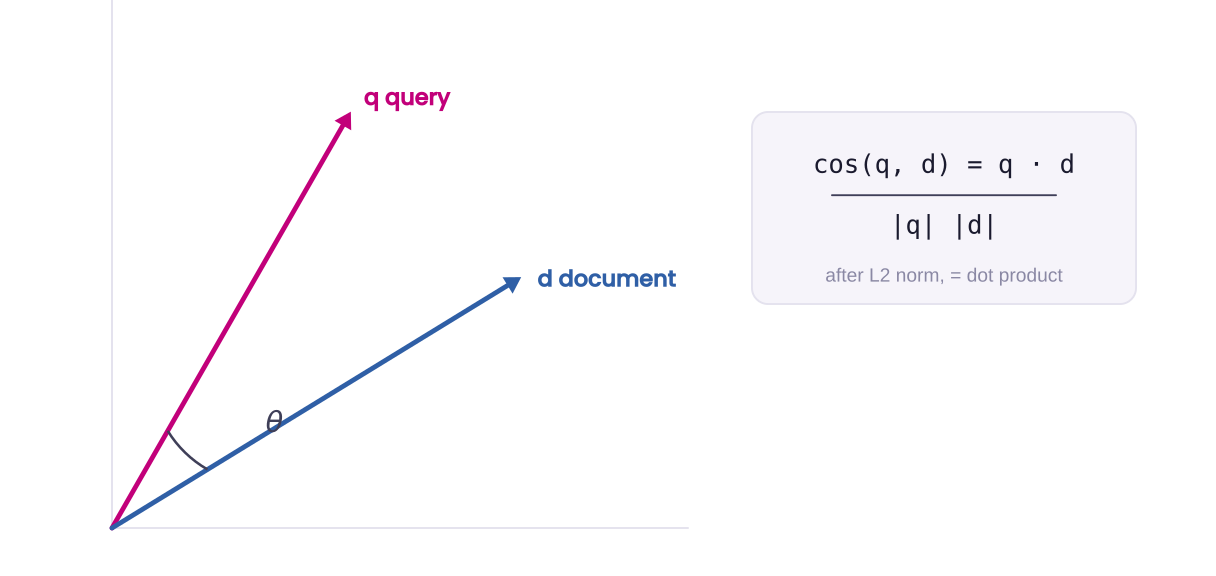

*Established. The picture below is the actual 64-chunk index projected to two dimensions.*

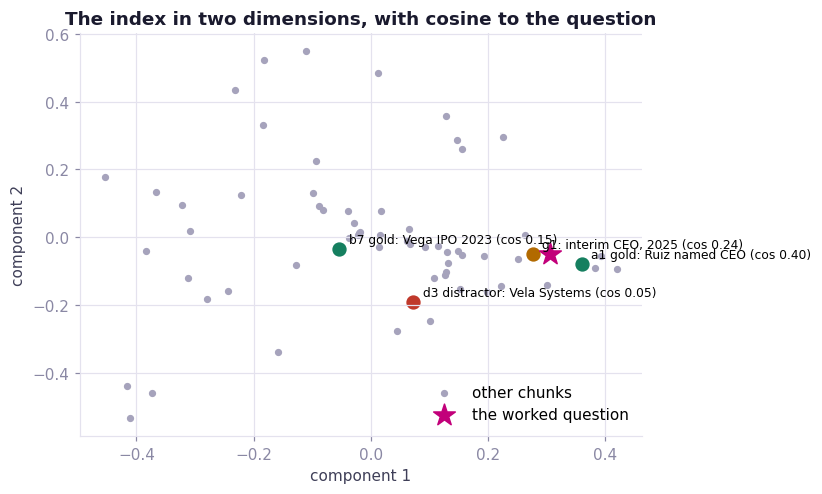

chunk,label,cosine to question
a1:0:63d9a4f8,a1 gold: Ruiz named CEO,0.402
g1:1:146112aa,"g1: interim CEO, 2025",0.236
b7:0:d9956799,b7 gold: Vega IPO 2023,0.153
d3:0:de051818,d3 distractor: Vela Systems,0.047


In [3]:
from sklearn.decomposition import PCA
V = retriever.flat.V; ids = retriever.flat.ids
qv = embedder.embed_one(anchor.text)
P = PCA(n_components=2, random_state=0).fit(V)
XY = P.transform(V); qxy = P.transform(qv.reshape(1, -1))[0]
highlight = {"a1:0:63d9a4f8": ("a1 gold: Ruiz named CEO", rk.palette.GREEN), "b7:0:d9956799": ("b7 gold: Vega IPO 2023", rk.palette.GREEN),
             "d3:0:1a6bd1d3": ("d3 distractor: Vela Systems", rk.palette.RED), "g1:1:146112aa": ("g1: interim CEO, 2025", rk.palette.COST)}
highlight = {k: v for k, v in highlight.items() if k in ids}
for cid in [c for c in ids if c.startswith("d3:0")]: highlight[cid] = ("d3 distractor: Vela Systems", rk.palette.RED)
fig_, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(XY[:, 0], XY[:, 1], s=14, color=rk.palette.DIM, label="other chunks")
for cid, (label, colour) in highlight.items():
    i = ids.index(cid); ax.scatter(XY[i, 0], XY[i, 1], s=70, color=colour); ax.annotate(f"{label} (cos {float(V[i] @ qv):.2f})", (XY[i, 0], XY[i, 1]), fontsize=8, xytext=(6, 4), textcoords="offset points")
ax.scatter([qxy[0]], [qxy[1]], marker="*", s=220, color=rk.palette.MAG, label="the worked question")
ax.set_title("The index in two dimensions, with cosine to the question"); ax.legend(loc="lower right"); ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
plt.tight_layout(); plt.show()
rows = [{"chunk": cid, "label": lab, "cosine to question": round(float(V[ids.index(cid)] @ qv), 3)} for cid, (lab, _) in highlight.items()]
table(pd.DataFrame(rows).sort_values("cosine to question", ascending=False), "Cosine values behind the plot")

| What the geometry says | What it cannot say |
|---|---|
| The gold appointment chunk and the interim-CEO chunk sit at a similar angle to the question, because they are about the same thing. | Which of them is dated 2026. Recency is metadata, and the angle does not carry it; the pre-filter from notebook 01 does. |
| The Vela Systems distractor sits far from the question under this embedder, since Turin, antennas and ground segment share little with the question's wording; the near miss here is the interim-CEO article. | A neural encoder trained on web text places two appoints-a-chief-executive articles closer together than LSA does, which is where distractor capture appears in production. Only an exact term match or a reranker reading both texts together tells the firms apart. |
| The IPO chunk is far from the question, and that is correct: the question never mentions an IPO or Vega Dynamics. | That the IPO chunk is needed anyway. No single-vector encoding of this question can reach hop two. |

Cosine on unit vectors equals the dot product, which is why every index here normalises at build time. Euclidean distance on the same unit vectors gives the same ranking, so the choice among them is a storage and indexing convenience, not a quality decision.

## 3 · Approximate search: recall is a knob you turn, not a property you get

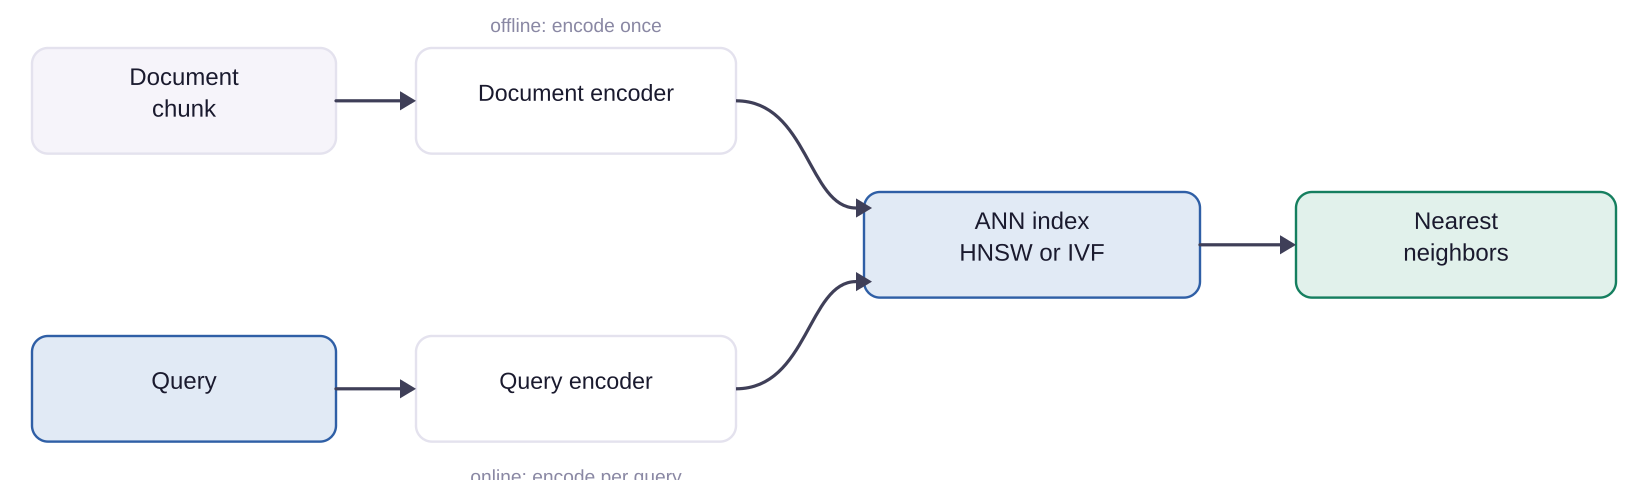

*Established. The cell builds an inverted-file index on the 64 chunks and turns its knob.*

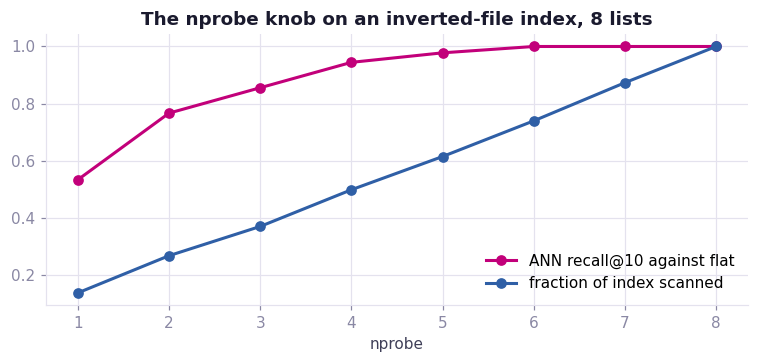

nprobe,ANN recall@10 vs flat,vectors scanned
1,0.533,8.800
2,0.767,17.100
3,0.856,23.700
4,0.944,31.900
5,0.978,39.300
6,1.000,47.300
7,1.000,55.900
8,1.000,64.000


In [4]:
ivf = rk.IVFIndex(ids, V, nlist=8)
flat = retriever.flat
answerable = [q for q in questions if q.gold]
probes = list(range(1, ivf.nlist + 1)); ann_recall, scanned = [], []
for npb in probes:
    rec, sc = [], []
    for q in answerable:
        qv_ = embedder.embed_one(q.text)
        truth = {cid for cid, _ in flat.search(qv_, k=10)}
        got = {cid for cid, _ in ivf.search(qv_, k=10, nprobe=npb)}
        rec.append(len(truth & got) / len(truth)); sc.append(ivf.scanned(qv_, nprobe=npb))
    ann_recall.append(float(np.mean(rec))); scanned.append(float(np.mean(sc)))
lines(probes, {"ANN recall@10 against flat": ann_recall, "fraction of index scanned": [s / len(ids) for s in scanned]}, "The nprobe knob on an inverted-file index, 8 lists", "nprobe", "")
table(pd.DataFrame({"nprobe": probes, "ANN recall@10 vs flat": np.round(ann_recall, 3), "vectors scanned": np.round(scanned, 1)}), "Measured on this index")

| Index | Strength | What it costs | Recall knob | Use when |
|---|---|---|---|---|
| Flat, exact | Recall is 1.0 by construction, with nothing to tune. | A linear scan, so latency grows with the corpus. | none | Under a few hundred thousand chunks, or as the ground truth you measure the others against. |
| HNSW graph | The best latency-to-recall trade in common use; supports incremental insert. | A memory-resident graph, typically a multiple of the raw vectors; deletes need compaction. | efSearch, M | The default for online serving. |
| IVF-PQ | Compresses vectors hard, so it fits where nothing else does. | Quantisation loses recall; it needs a training pass and periodic retraining. | nprobe, nlist | Hundreds of millions of vectors on limited RAM. |
| Disk-based graph | Billions of vectors at SSD cost rather than RAM cost. | Higher and noisier tail latency; slow rebuilds. | beam width | Archive-scale corpora. |

The matrix is taken from the advanced-track deck; the memory multiples are typical figures, not measurements. Two rules survive every index choice. Measure ANN recall against a flat scan on a sample, because an approximate miss is invisible to every downstream metric. And test recall with your real filters, because a highly selective pre-filter can strand a graph traversal in a sparse region.

In [5]:
INDEX_TREE = [
    {"q": "Under about 500k vectors, or is this the ground-truth index?", "test": lambda f: f["n_vectors"] < 500_000 or f["ground_truth"], "yes": "flat, exact search", "no": None, "show": lambda f: f"n_vectors={f['n_vectors']:,}"},
    {"q": "Do the raw vectors fit in RAM with room for a graph?", "test": lambda f: f["vectors_gb"] * 2 < f["ram_gb"], "yes": None, "no": "IVF-PQ if RAM is the limit, a disk-based graph if the corpus is archive scale", "show": lambda f: f"vectors {f['vectors_gb']} GB, RAM {f['ram_gb']} GB"},
    {"q": "Are pre-filters highly selective (tenant, ACL)?", "test": lambda f: f["selective_filters"], "yes": "HNSW partitioned per tenant or namespace, and measure filtered recall", "no": "HNSW with efSearch tuned against a flat sample", "show": lambda f: f"selective_filters={f['selective_filters']}"},
]
display(table(decision(INDEX_TREE, {"n_vectors": len(ids), "ground_truth": False, "vectors_gb": 0.0, "ram_gb": 16, "selective_filters": False}), "This corpus"))
display(table(decision(INDEX_TREE, {"n_vectors": 50_000_000, "ground_truth": False, "vectors_gb": 300, "ram_gb": 128, "selective_filters": True}), "A 50 million vector, 1536-dimension deployment on a 128 GB box"))
table(decision(INDEX_TREE, {"n_vectors": 5_000_000, "ground_truth": False, "vectors_gb": 30, "ram_gb": 128, "selective_filters": True}), "Five million vectors with per-tenant filters")

question,measured,answer
"Under about 500k vectors, or is this the ground-truth index?",n_vectors=64,yes
Outcome,,"flat, exact search"


question,measured,answer
"Under about 500k vectors, or is this the ground-truth index?","n_vectors=50,000,000",no
Do the raw vectors fit in RAM with room for a graph?,"vectors 300 GB, RAM 128 GB",no
Outcome,,"IVF-PQ if RAM is the limit, a disk-based graph if the corpus is archive scale"


question,measured,answer
"Under about 500k vectors, or is this the ground-truth index?","n_vectors=5,000,000",no
Do the raw vectors fit in RAM with room for a graph?,"vectors 30 GB, RAM 128 GB",yes
"Are pre-filters highly selective (tenant, ACL)?",selective_filters=True,yes
Outcome,,"HNSW partitioned per tenant or namespace, and measure filtered recall"


## 4 · Selecting an embedding model is a deployment decision first

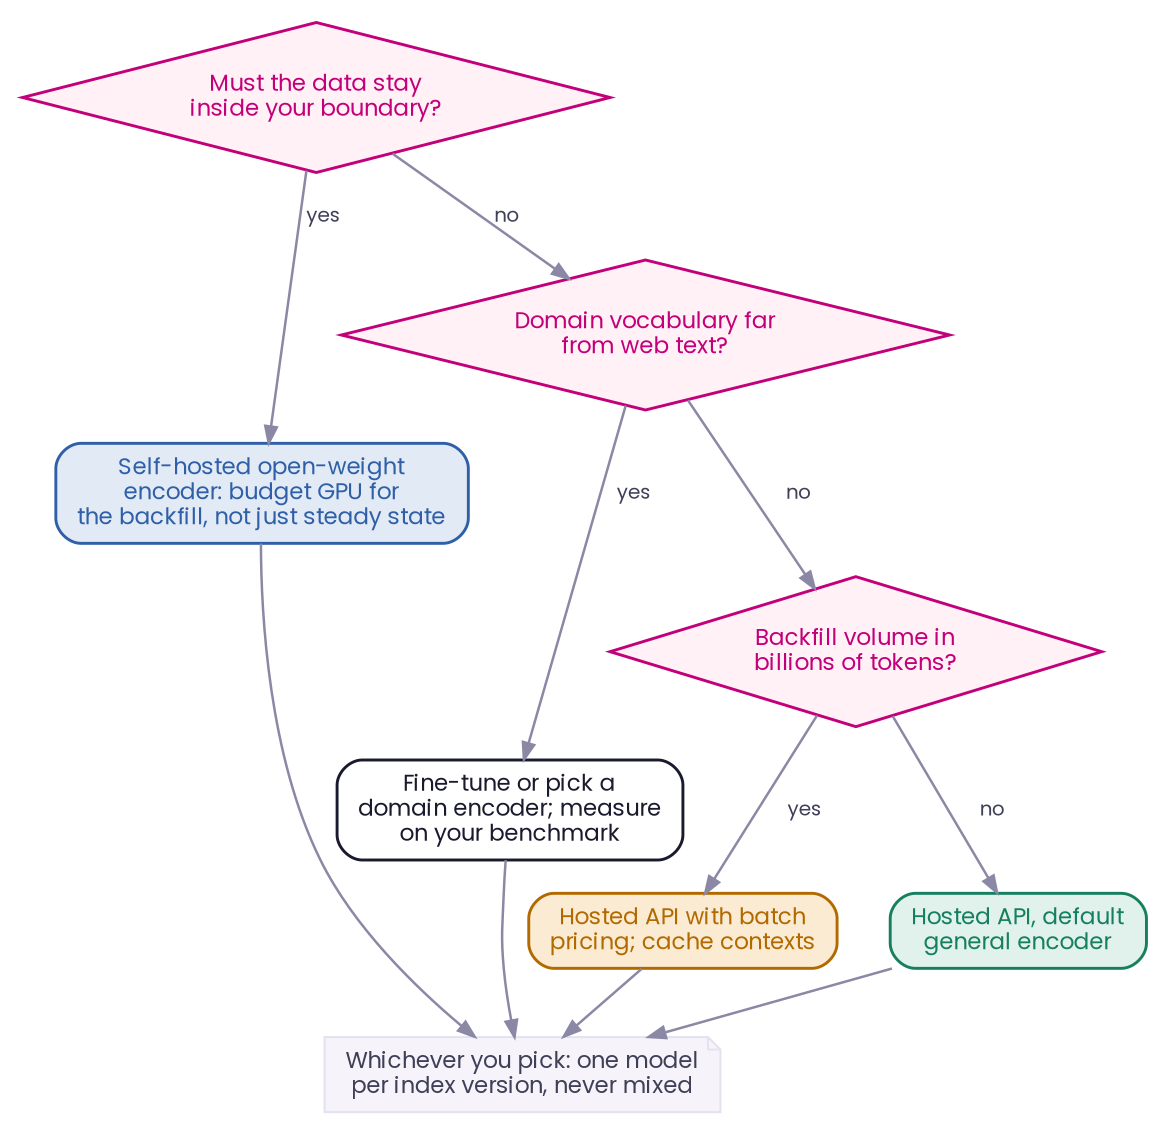

*From the advanced-track deck, extended with the never-mix rule from notebook 03. The runner executes it on two scenarios.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    q1{"Must the data stay<br/>inside your boundary?"}
    self["Self-hosted open-weight<br/>encoder: budget GPU for<br/>the backfill, not just steady state"]
    q2{"Domain vocabulary far<br/>from web text?"}
    ft["Fine-tune or pick a<br/>domain encoder; measure<br/>on your benchmark"]
    q3{"Backfill volume in<br/>billions of tokens?"}
    cost["Hosted API with batch<br/>pricing; cache contexts"]
    api["Hosted API, default<br/>general encoder"]
    rule["Whichever you pick: one model<br/>per index version, never mixed"]
    q1 -->|yes| self
    q1 -->|no| q2
    q2 -->|yes| ft
    q2 -->|no| q3
    q3 -->|yes| cost
    q3 -->|no| api
    api --> rule
    cost --> rule
    ft --> rule
    self --> rule
    class q1 dec
    class self tool
    class q2 dec
    class q3 dec
    class cost cost
    class api ok
    class rule note
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [6]:
MODEL_TREE = [
    {"q": "Must the data stay inside your boundary?", "test": lambda f: f["data_residency"], "yes": "self-hosted open-weight encoder; budget GPU capacity for the initial backfill", "no": None, "show": lambda f: f"data_residency={f['data_residency']}"},
    {"q": "Is the domain vocabulary far from web text?", "test": lambda f: f["domain_gap"], "yes": "domain encoder or fine-tune, and measure it on your benchmark before the backfill", "no": None, "show": lambda f: f"domain_gap={f['domain_gap']}"},
    {"q": "Is the backfill in billions of tokens?", "test": lambda f: f["backfill_tokens"] >= 1e9, "yes": "hosted API on batch pricing; contextualise with a cached document prefix", "no": "hosted API, general encoder, re-benchmark on every model version", "show": lambda f: f"backfill_tokens={f['backfill_tokens']:,.0f}"},
]
display(table(decision(MODEL_TREE, {"data_residency": False, "domain_gap": False, "backfill_tokens": 2e5}), "A public news corpus like this one"))
table(decision(MODEL_TREE, {"data_residency": True, "domain_gap": True, "backfill_tokens": 3e9}), "A bank's internal policy corpus")

question,measured,answer
Must the data stay inside your boundary?,data_residency=False,no
Is the domain vocabulary far from web text?,domain_gap=False,no
Is the backfill in billions of tokens?,"backfill_tokens=200,000",no
Outcome,,"hosted API, general encoder, re-benchmark on every model version"


question,measured,answer
Must the data stay inside your boundary?,data_residency=True,yes
Outcome,,self-hosted open-weight encoder; budget GPU capacity for the initial backfill


| If | Then | Because |
|---|---|---|
| The data cannot leave your boundary. | Self-host an open-weight encoder and budget the backfill GPU, not only the steady state. | The one-time embedding of the corpus is usually the largest compute event the system ever has. |
| The vocabulary is far from web text (clinical, legal, your own product names). | Measure a domain encoder or a fine-tune on your benchmark before the backfill. | A general encoder places your terms by their web meaning, which may be wrong or absent. |
| Any model change ships. | New index version, shadow-evaluated, alias-swapped. | Vectors from two models are not comparable, as notebook 03 measured. |

## 5 · Hybrid: two ranked lists, fused by rank

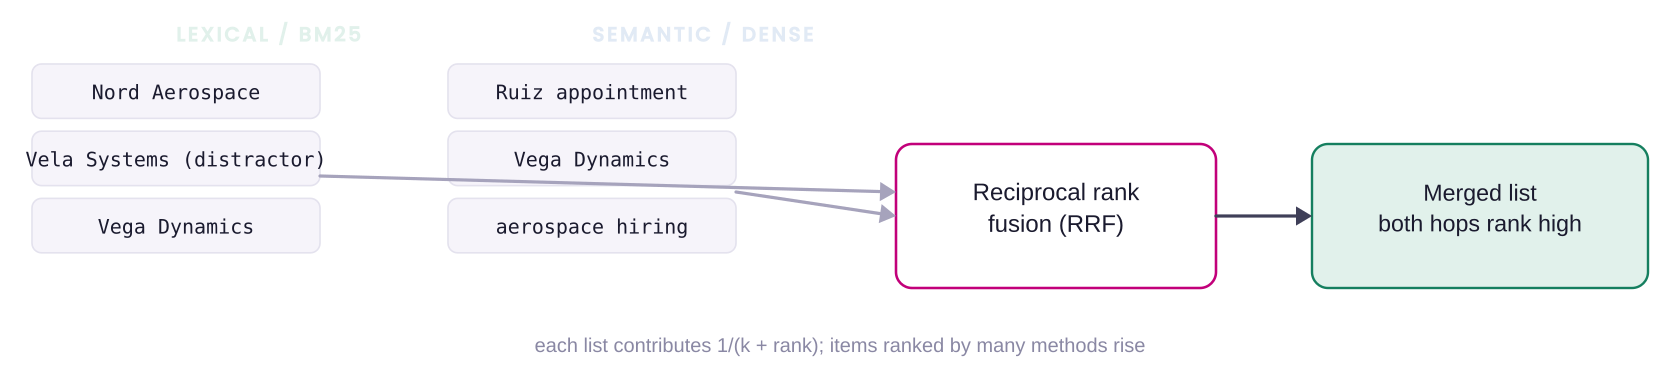

*Established (Cormack, Clarke and Buettcher, 2009). Each list contributes 1 / (k + rank); the cell shows every contribution.*

In [7]:
lex = retriever.lexical(anchor.text, k=50); den = retriever.dense(anchor.text, k=50)
fused = rk.rrf([lex, den], k=60)
lrank = {cid: r for r, (cid, _) in enumerate(lex, 1)}; drank = {cid: r for r, (cid, _) in enumerate(den, 1)}
rows = [{"fused rank": r, "chunk": cid, "lexical rank": lrank.get(cid, "absent"), "dense rank": drank.get(cid, "absent"),
         "RRF score": round(s, 5), "text": texts[cid][:60] + "..."} for r, (cid, s) in enumerate(fused[:8], 1)]
display(table(pd.DataFrame(rows), "The fused top 8 for the worked question, with each list's rank shown"))
w = rk.weighted([lex, den], [0.5, 0.5])
gold_ids = [sorted(s)[0] for s in rk.gold_chunk_sets(anchor, chunks)]
cmp = pd.DataFrame([{"method": m, "a1 gold rank": [c for c, _ in L].index(gold_ids[0]) + 1, "b7 gold rank": [c for c, _ in L].index(gold_ids[1]) + 1}
                    for m, L in [("lexical only", lex), ("dense only", den), ("RRF fusion", fused), ("weighted z-score fusion", w)]])
table(cmp, "Where the two gold chunks land under each method")

fused rank,chunk,lexical rank,dense rank,RRF score,text
1,g2:0:7465c618,1,1,0.033,Nord Aerospace expands Bergen test site. Nord Aerospace bega...
2,a1:2:8d2011b6,4,2,0.032,Nord Aerospace names Elena Ruiz chief executive. Ruiz said t...
3,b7:1:eb0b8d13,3,3,0.032,Vega Dynamics shares jump in Nasdaq debut. Chief executive E...
4,g2:1:759cdda7,2,5,0.032,Nord Aerospace expands Bergen test site. The stand will supp...
5,k3:1:3ea2bfbe,6,4,0.031,Kestrel Foods revenue flat at 3.1 billion euros. The company...
6,r1:0:7e49a71b,5,7,0.030,The year in European listings. European companies raised les...
7,a1:0:63d9a4f8,7,6,0.030,Nord Aerospace names Elena Ruiz chief executive. Nord Aerosp...
8,l3:1:b31c0299,8,8,0.029,Lumen Bio phase 3 trial meets primary endpoint. Chief execut...


method,a1 gold rank,b7 gold rank
lexical only,7,17
dense only,6,19
RRF fusion,7,19
weighted z-score fusion,6,18


For this question fusion lifts neither gold chunk, because both lists agree on the same siblings and RRF rewards agreement. Fusion earns its place where the lists disagree, as on the paraphrase query in notebook 01, where dense found the appointment article and lexical did not.

| Fusion | How it combines | When it is the right choice |
|---|---|---|
| Reciprocal rank fusion | Sums 1 / (k + rank) across lists, so an item ranked well by both rises without any score calibration. | The default. BM25 scores and cosine values live on different scales and RRF never compares them. |
| Weighted score fusion | Standardises each list's scores and adds them with weights. | When you have a benchmark to tune the weights on and a reason to trust one list more, for example identifier-heavy traffic. |
| Learned fusion | A small model over both scores plus features. | When traffic is large enough that a per-query weighting pays back its own evaluation cost. |

## 6 · Grep: the retrieval mode with no index at all

An agent working in a repository or a log directory often needs an exact pattern more than a ranked list, and it needs it against files that were never indexed. The cell measures the cost of each mode on the same identifier.

In [8]:
t = rk.Timer()
with t.stage("grep over 64 chunks"):
    g = rk.grep(chunks, r"VD-7")
with t.stage("BM25 lookup"):
    l = retriever.lexical("VD-7", k=5)
with t.stage("dense: embed query and scan"):
    d = retriever.dense("VD-7 engine designation", k=5)
display(table(t.table(), "Wall-clock milliseconds on this machine for one identifier query"))
print("grep hits:", [(h["doc_id"], h["line"]) for h in g])
print("BM25 top-3 docs:", [c.split(":")[0] for c, _ in l[:3]], "| dense top-3 docs:", [c.split(":")[0] for c, _ in d[:3]])

stage,ms
grep over 64 chunks,0.220
BM25 lookup,0.030
dense: embed query and scan,0.720


grep hits: [('b7', 3), ('e2', 2), ('g3', 1), ('g3', 2), ('g3', 1), ('g3', 2)]
BM25 top-3 docs: ['g3', 'g3', 'b7'] | dense top-3 docs: ['g3', 'g3', 'b7']


| Dimension | Indexed retrieval | Agentic grep |
|---|---|---|
| Freshness | As fresh as the last index run, so a file edited a minute ago is invisible. | Always current, since it reads the files as they are. |
| Setup cost | Parse, chunk, embed and store the corpus before the first query. | None. |
| Per-query cost | Milliseconds and predictable. | Grows with the size of the tree and the number of patterns the agent tries. |
| Paraphrase | Handled by the dense side of a hybrid index. | Not handled at all; the agent must guess the literal string. |
| Multi-hop | Needs decomposition, notebook 08. | The agent's loop is the decomposition; each grep is one hop. |

Code assistants split on exactly this line: some index the repository and retrieve, others give the model grep and let it search. Neither is wrong; they pay for different things.

## 7 · Reranking: what it does, and what it bought here

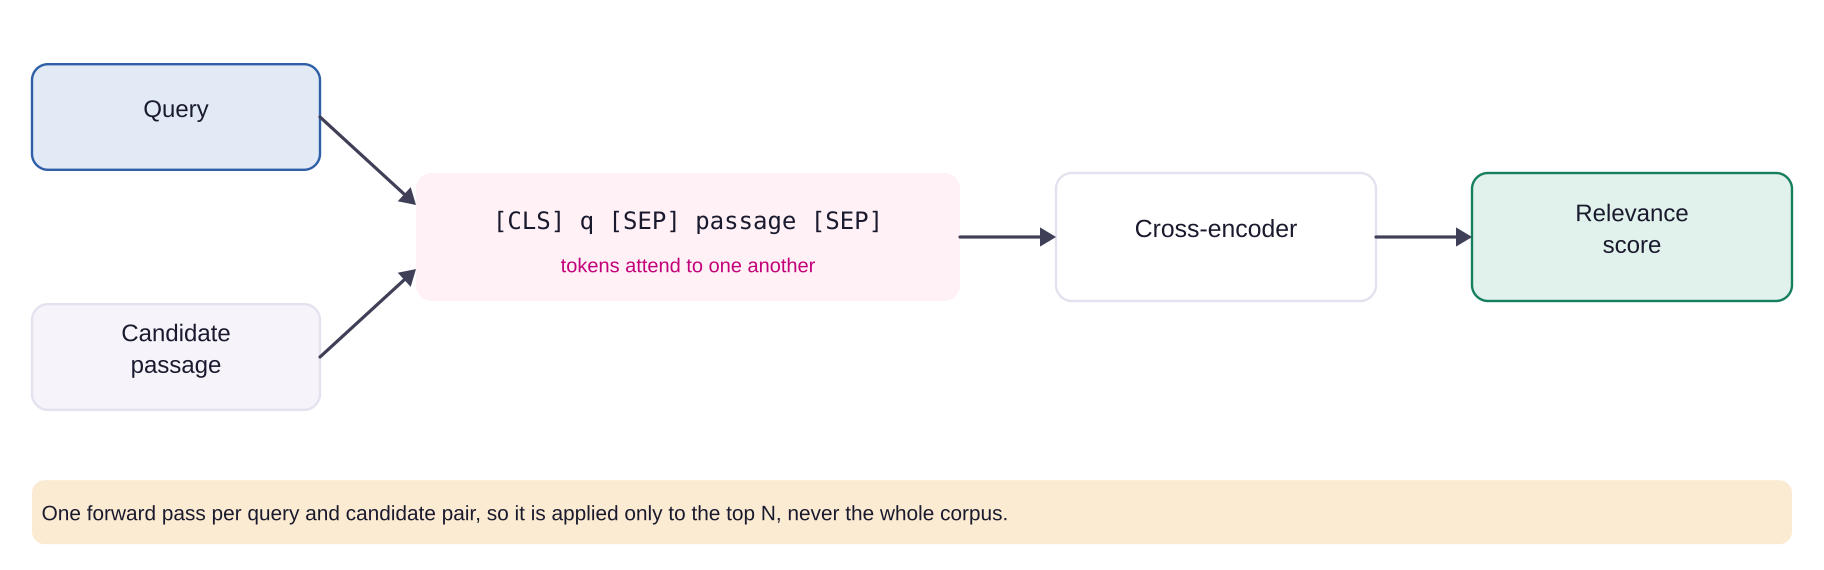

*Established. High quality, and expensive per pair, so it runs over a pool of tens, never the corpus.*

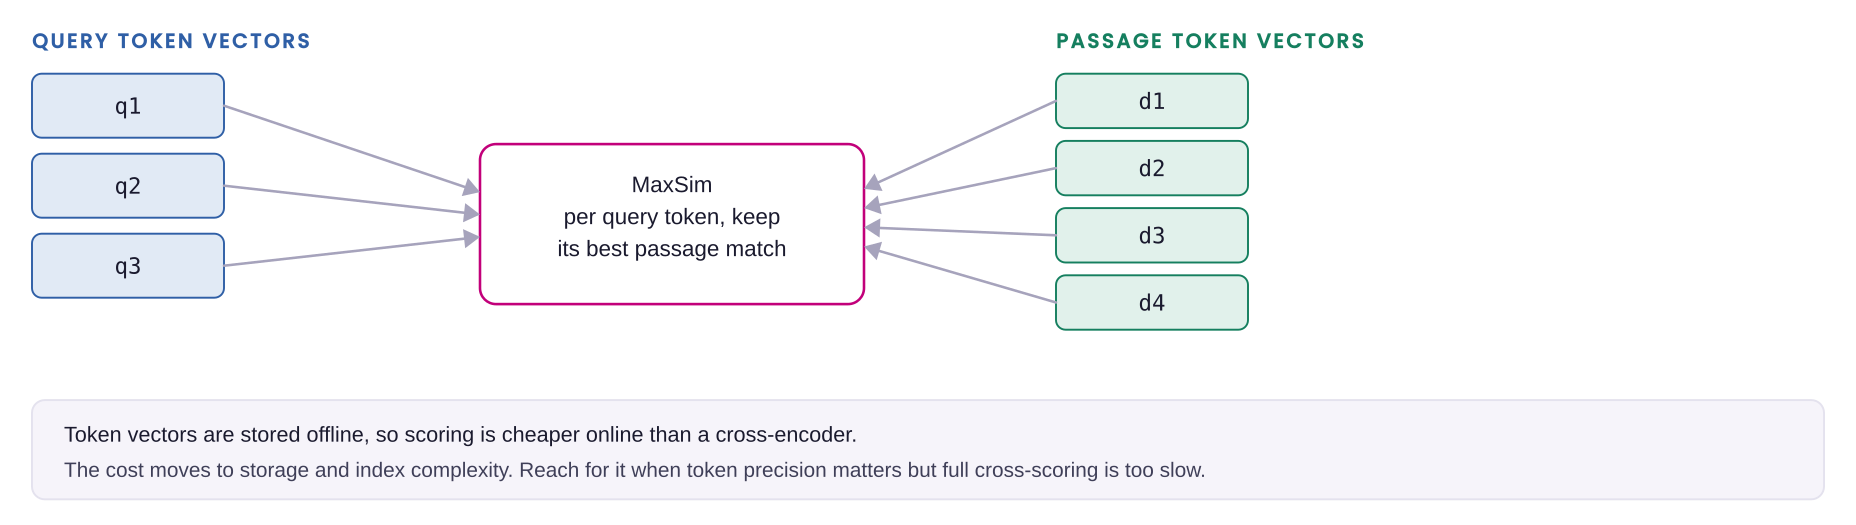

*Established (the ColBERT idea). The cell below computes exactly this matrix on the LSA term vectors.*

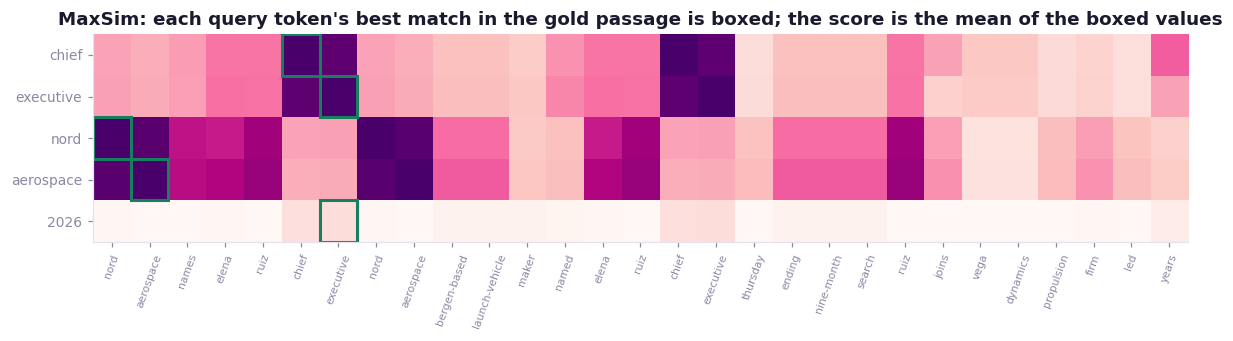

MaxSim score for the hop-one question against the gold chunk: 0.828, against the Vela distractor: 0.634


In [9]:
ms = rk.MaxSimReranker(embedder).bind(texts)
hop1 = "who became chief executive of Nord Aerospace in 2026"
qt, pt, M = ms.matrix(hop1, texts["a1:0:63d9a4f8"])
fig_, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(M, cmap="RdPu", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(pt))); ax.set_xticklabels(pt, rotation=70, fontsize=7); ax.set_yticks(range(len(qt))); ax.set_yticklabels(qt, fontsize=9); ax.grid(False)
for i in range(len(qt)):
    j = int(M[i].argmax()); ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=rk.palette.GREEN, linewidth=2))
ax.set_title("MaxSim: each query token's best match in the gold passage is boxed; the score is the mean of the boxed values")
plt.tight_layout(); plt.show()
print(f"MaxSim score for the hop-one question against the gold chunk: {ms.score(hop1, texts['a1:0:63d9a4f8']):.3f}, against the Vela distractor: {ms.score(hop1, [t for c, t in texts.items() if c.startswith('d3:0')][0]):.3f}")

Now the measurement. The pool of 50 from hybrid retrieval is reranked, and the rank of every gold chunk is recorded before and after.

In [10]:
rr = rk.make_reranker("maxsim", retriever, texts, top=50)
rows = []
for q in answerable:
    pool = retriever.hybrid(q.text, k=50); after = rr(q.text, pool)
    gs = rk.gold_chunk_sets(q, chunks)
    worst = lambda L: max(min([c for c, _ in L].index(c) + 1 for c in s) for s in gs)
    rows.append({"qid": q.qid, "type": q.qtype, "worst gold rank before": worst(pool), "worst gold rank after MaxSim": worst(after)})
ranks = pd.DataFrame(rows)
display(table(ranks, "Worst-ranked gold chunk per question, hybrid pool of 50, before and after late-interaction reranking"))
base = rk.summarize(rk.run_benchmark(rk.RunConfig("hybrid_k5", mode="hybrid", k=5), retriever, generator, questions, chunks), "hybrid k=5")
rer = rk.summarize(rk.run_benchmark(rk.RunConfig("maxsim_k5", mode="hybrid", k=5, reranker=rr), retriever, generator, questions, chunks), "hybrid + MaxSim, k=5")
table(pd.DataFrame([base, rer]).reset_index().rename(columns={"index": "config"}), "Benchmark at k=5 with and without the reranker")

qid,type,worst gold rank before,worst gold rank after MaxSim
q01,inference,19,14
q02,inference,2,2
q03,inference,9,15
q04,comparison,2,2
q05,comparison,2,2
q06,comparison,2,5
q07,temporal,2,2
q08,temporal,4,5
q09,temporal,3,2


config,recall@k,full_chain@k,recall@pool,ndcg@k,coverage,correct,faithful,null_abstained,evidence_tokens
hybrid k=5,0.833,0.778,1.000,0.823,0.833,0.833,1.000,1.000,229.167
"hybrid + MaxSim, k=5",0.833,0.778,1.000,0.740,0.833,0.833,1.000,1.000,233.583


| What the table shows | Why it happened | What it means for the design |
|---|---|---|
| For the comparison and temporal questions the gold chunks already sit at ranks 1 to 4, inside k=5, before reranking. | On 64 chunks, hybrid first-stage retrieval is already precise for single-hop facts. | There is no recall to convert into precision, so a reranker has nothing to buy. Measure stage one before adding stage two. |
| nDCG at k fell from about 0.82 to about 0.74 after reranking, and three questions got a worse gold rank. | The stand-in scores token-level similarity, which favours chunks that repeat the question's words over chunks that answer it. | A reranker that is not trained on relevance is a way of spending recall, not converting it. |
| For the inference questions the worst gold chunk stays far down after reranking. | The second-hop chunk is not relevant to the question as written: it never mentions Nord Aerospace or a chief executive. | No reranker over the full question can lift it. This is a dependency gap, and the fix is decomposition (notebook 08) or a larger k (notebook 05), not a better scorer. |
| The offline reranker is late interaction over LSA term vectors, not a trained cross-encoder. | The stand-in is the mechanism without the training. | A real reranker is one config line away in the next cell; the shape of the argument does not change. |

### What the smallest trained reranker learns from seven questions

A reranker is a trained model. The cell trains the smallest possible one, a logistic regression over nine query-passage features, on the tuning slice, then checks the frozen slice. Read the coefficients before the ranks.

In [11]:
import re
from sklearn.linear_model import LogisticRegression
def features(q_text, cid, bm_score, cos):
    t = texts[cid]; qt_ = set(rk.tokenize(q_text)); pt_ = set(rk.tokenize(t))
    caps_q = {w.strip(",.?'s") for w in q_text.split() if w[:1].isupper()}; caps_p = {w.strip(",.?'s") for w in t.split() if w[:1].isupper()}
    return [bm_score, cos, ms.score(q_text, t), len(qt_ & pt_) / max(1, len(qt_)), len(caps_q & caps_p),
            len(re.findall(r"\b(19|20)\d\d\b", t)), len(re.findall(r"\d+ (million|billion)", t)), len(pt_) / 100]
NAMES = ["bm25", "cosine", "maxsim", "term overlap", "shared proper nouns", "years mentioned", "money mentioned", "length"]
def pool_with_features(q_text):
    pool = retriever.hybrid(q_text, k=50); bm_ = dict(retriever.lexical(q_text, k=64)); qv_ = embedder.embed_one(q_text)
    return pool, [(cid, features(q_text, cid, bm_.get(cid, 0.0), float(V[ids.index(cid)] @ qv_))) for cid, _ in pool]
tune = [q for q in answerable if not q.frozen]; frozen = [q for q in answerable if q.frozen]
X, y = [], []
for q in tune:
    gold = set().union(*rk.gold_chunk_sets(q, chunks)); _, rows_ = pool_with_features(q.text)
    for cid, f in rows_: X.append(f); y.append(int(cid in gold))
clf = LogisticRegression(class_weight="balanced", max_iter=3000).fit(np.array(X), np.array(y))
display(table(pd.DataFrame({"feature": NAMES, "coefficient": np.round(clf.coef_[0], 2)}).sort_values("coefficient", ascending=False), f"Trained on {len(tune)} questions, {len(X)} query-passage pairs, {sum(y)} positives"))
def learned(q_text, ranked):
    _, rows_ = pool_with_features(q_text); sc = {cid: float(clf.decision_function([f])[0]) for cid, f in rows_}
    return sorted([(cid, sc[cid]) for cid, _ in ranked], key=lambda x: -x[1])
out = []
for label, group in [("tuning", tune), ("frozen", frozen)]:
    for q in group:
        pool = retriever.hybrid(q.text, k=50); gs = rk.gold_chunk_sets(q, chunks)
        worst = lambda L: max(min([c for c, _ in L].index(c) + 1 for c in s) for s in gs)
        out.append({"slice": label, "qid": q.qid, "worst gold rank before": worst(pool), "after trained reranker": worst(learned(q.text, pool))})
table(pd.DataFrame(out), "Before and after, tuning slice and frozen slice")

feature,coefficient
money mentioned,1.610
length,1.070
cosine,0.700
bm25,0.510
shared proper nouns,0.040
term overlap,-0.250
years mentioned,-0.320
maxsim,-0.520


slice,qid,worst gold rank before,after trained reranker
tuning,q01,19,11
tuning,q02,2,2
tuning,q03,9,3
tuning,q04,2,2
tuning,q05,2,2
tuning,q06,2,2
tuning,q07,2,2
frozen,q08,4,3
frozen,q09,3,2


| What the coefficients say | The lesson |
|---|---|
| The largest positive weights sit on money mentioned and passage length, ahead of any relevance signal. | The model learned the benchmark's fingerprint: gold spans in this set tend to state a sum of money. That is the eval set's blind spot from notebook 02, now baked into a ranker. |
| The ranks improve on the tuning slice and move little on the frozen slice. | A gain that lives on the slice you trained on is not a gain. The frozen slice is the number to report. |
| A production cross-encoder is trained on millions of pairs from many corpora. | The mechanism is the same as this cell; the difference is that it learned relevance rather than your set's artefacts. Evaluate it on your frozen slice all the same. |

### With a provider configured, the real thing runs through the same hook

`make_reranker("llm", ...)` asks the configured model to score each passage; `make_reranker("bedrock", ...)` calls Bedrock's rerank endpoint (verified 2026-08-31: `bedrock-agent-runtime.rerank` with a `BEDROCK_RERANKING_MODEL` configuration and a model ARN such as `cohere.rerank-v3-5:0`). Both return the same `(query, ranked) -> ranked` callable, so the benchmark cell above runs unchanged.

In [12]:
if rk.config()["provider"] == "bedrock":
    real = rk.make_reranker("bedrock", retriever, texts, top=50)
    real_run = rk.summarize(rk.run_benchmark(rk.RunConfig("bedrock_rerank_k5", mode="hybrid", k=5, reranker=real), retriever, generator, questions, chunks), "hybrid + Bedrock rerank, k=5")
    display(table(pd.DataFrame([base, real_run]).reset_index().rename(columns={"index": "config"}), "Real reranker"))
else:
    print("provider is mock; set RAGKIT_PROVIDER=bedrock (and AWS credentials) to run Bedrock's reranker through the same hook")

provider is mock; set RAGKIT_PROVIDER=bedrock (and AWS credentials) to run Bedrock's reranker through the same hook


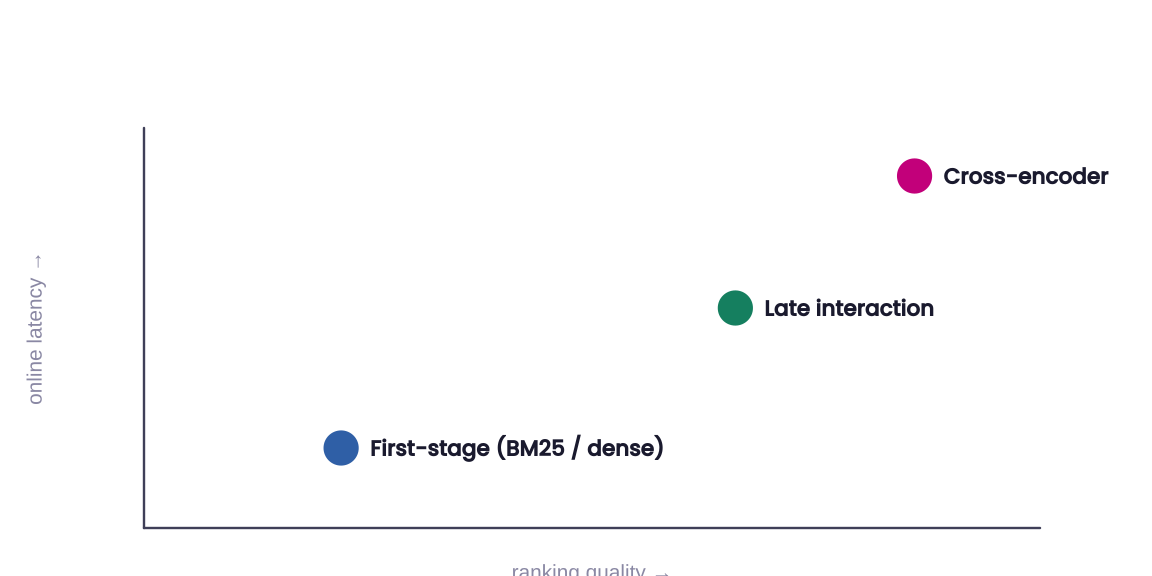

*From the session deck. Numbers are typical, not measured here.*

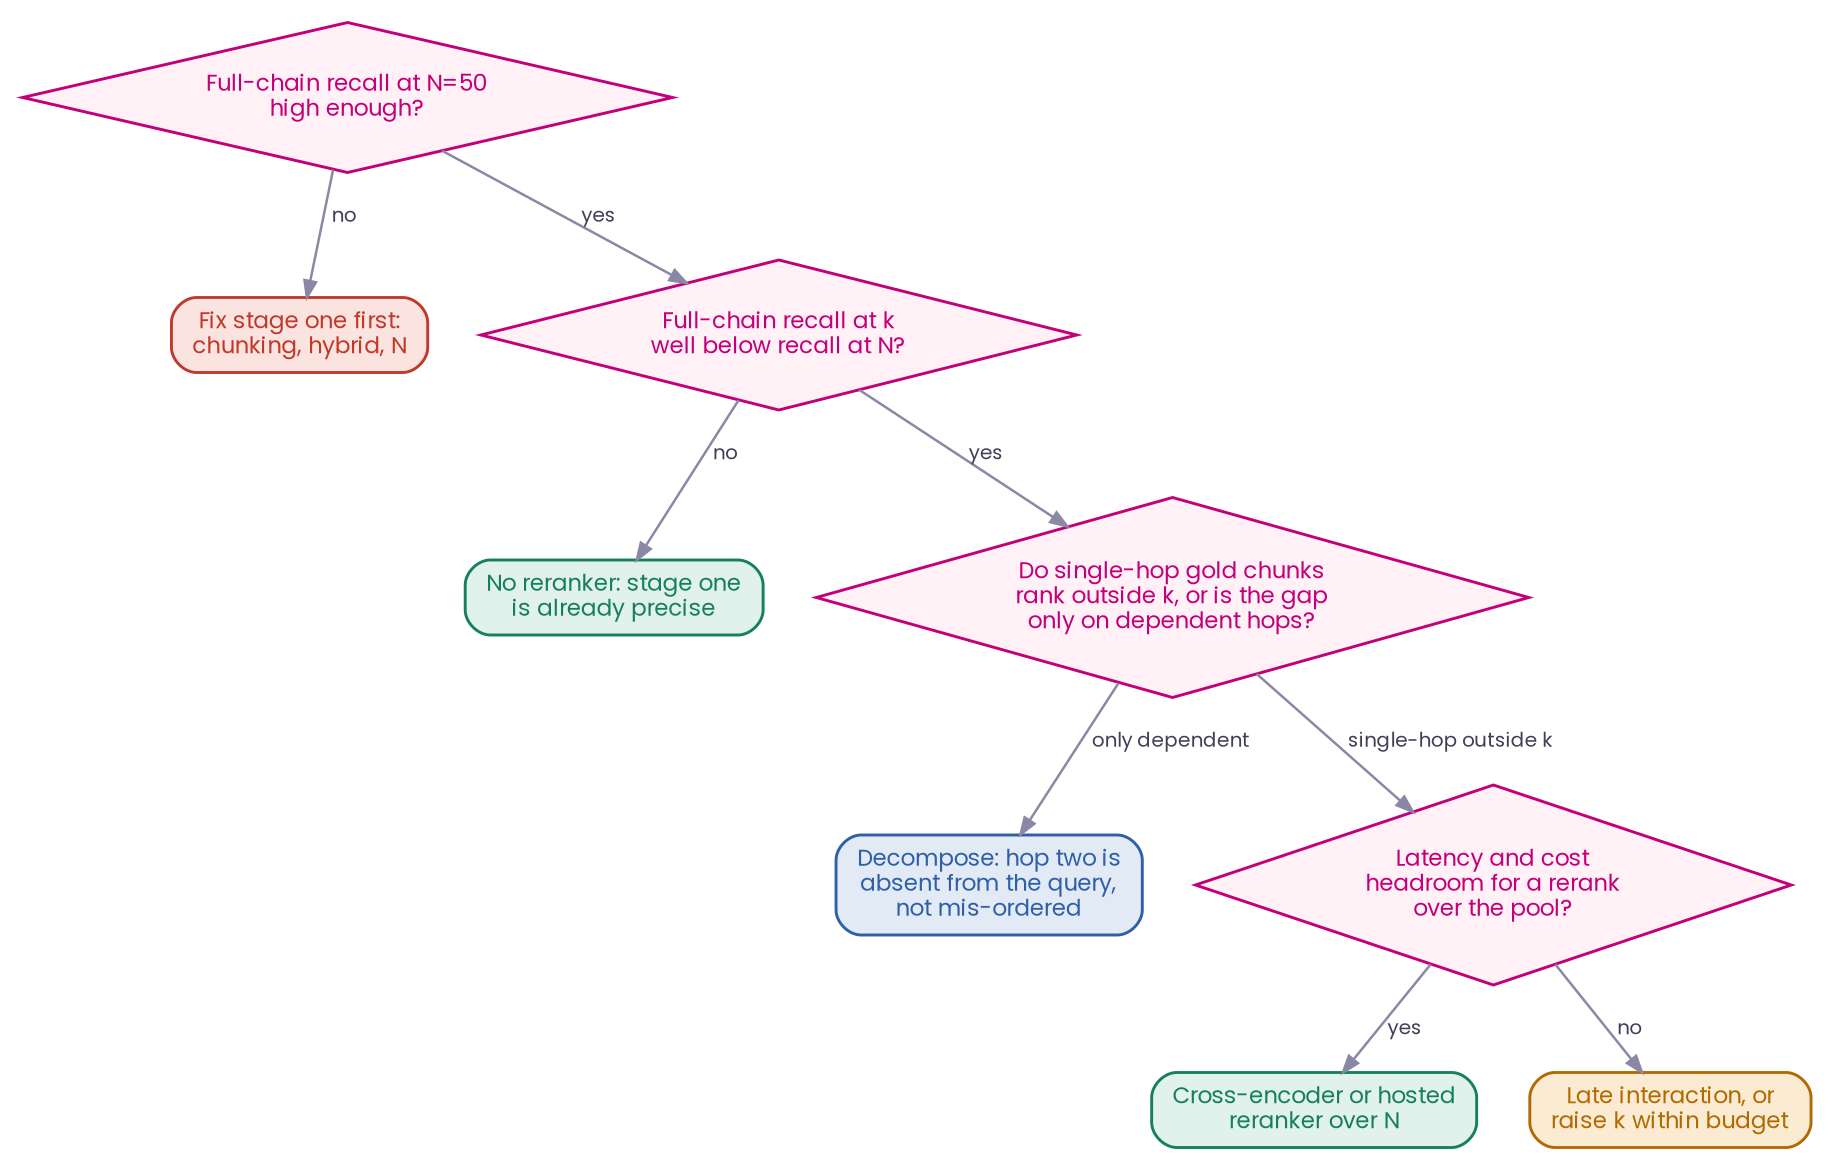

*Own construction, extending the deck's reranker tree with the dependency question this corpus forced. Executed below on the measured numbers.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    q1{"Full-chain recall at N=50<br/>high enough?"}
    fix1["Fix stage one first:<br/>chunking, hybrid, N"]
    q2{"Full-chain recall at k<br/>well below recall at N?"}
    none["No reranker: stage one<br/>is already precise"]
    q3{"Do single-hop gold chunks<br/>rank outside k, or is the gap<br/>only on dependent hops?"}
    decomp["Decompose: hop two is<br/>absent from the query,<br/>not mis-ordered"]
    q4{"Latency and cost<br/>headroom for a rerank<br/>over the pool?"}
    cross["Cross-encoder or hosted<br/>reranker over N"]
    late["Late interaction, or<br/>raise k within budget"]
    q1 -->|no| fix1
    q1 -->|yes| q2
    q2 -->|no| none
    q2 -->|yes| q3
    q3 -->|only dependent| decomp
    q3 -->|single-hop outside k| q4
    q4 -->|yes| cross
    q4 -->|no| late
    class q1 dec
    class fix1 fail
    class q2 dec
    class none ok
    class q3 dec
    class decomp tool
    class q4 dec
    class cross ok
    class late cost
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [13]:
single_hop_worst = int(ranks[ranks["type"] != "inference"]["worst gold rank before"].max())
facts = {"recall_at_50": float(base["recall@pool"]), "full_chain_at_k": float(base["full_chain@k"]), "single_hop_worst_rank": single_hop_worst, "k": 5, "latency_headroom_ms": 400}
RERANK_TREE = [
    {"q": "Is full-chain recall at N=50 high enough?", "test": lambda f: f["recall_at_50"] >= 0.9, "yes": None, "no": "fix stage one first", "show": lambda f: f"recall@50={f['recall_at_50']:.2f}"},
    {"q": "Is full-chain recall at k well below recall at N?", "test": lambda f: f["recall_at_50"] - f["full_chain_at_k"] >= 0.1, "yes": None, "no": "no reranker: stage one is already precise", "show": lambda f: f"full_chain@5={f['full_chain_at_k']:.2f}"},
    {"q": "Do single-hop gold chunks rank outside k, or is the gap only on dependent hops?", "test": lambda f: f["single_hop_worst_rank"] > f["k"], "yes": None, "no": "decompose: the gap is a dependency gap, not an ordering gap", "show": lambda f: f"worst single-hop gold rank={f['single_hop_worst_rank']}, k={f['k']}"},
    {"q": "Is there latency and cost headroom for a rerank over the pool?", "test": lambda f: f["latency_headroom_ms"] >= 250, "yes": "cross-encoder or hosted reranker over N", "no": "late interaction, or raise k within budget", "show": lambda f: f"headroom={f['latency_headroom_ms']} ms"},
]
table(decision(RERANK_TREE, facts), "The reranker decision on this corpus")

question,measured,answer
Is full-chain recall at N=50 high enough?,recall@50=1.00,yes
Is full-chain recall at k well below recall at N?,full_chain@5=0.78,yes
"Do single-hop gold chunks rank outside k, or is the gap only on dependent hops?","worst single-hop gold rank=4, k=5",no
Outcome,,"decompose: the gap is a dependency gap, not an ordering gap"


| If | Then | Because |
|---|---|---|
| Full-chain recall at N=50 is low. | Fix chunking, hybrid weights or N before anything else. | A reranker cannot exceed the ceiling stage one set. |
| Recall at N is high and recall at k is close to it. | Skip the reranker. | Stage one is already precise; a reranker adds latency for nothing. |
| The gap between N and k exists only on dependent multi-hop questions, and every single-hop gold chunk already ranks inside k. | Decompose the question, do not rerank. | The missing chunk is not mis-ordered; it is not relevant to the question as written. |
| Single-hop gold ranks outside k and the budget has a few hundred milliseconds of headroom. | A cross-encoder or hosted reranker over the pool. | That is the case where converting recall into precision pays. |

## 8 · Spending a 2.5 second p95 on one grounded answer

The budget below is illustrative, taken from the advanced-track deck, and it is placed next to what this toolkit measured on this machine so the proportions can be compared. Generation dominates, and retrieval quality is nearly free in latency terms.

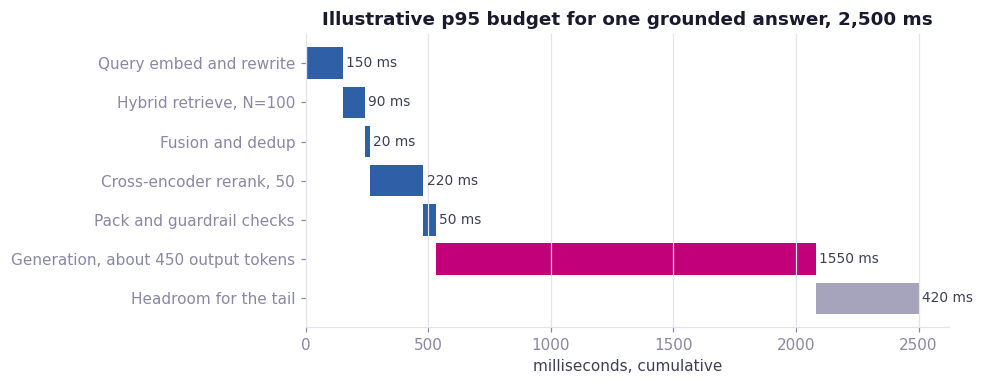

stage,ms
query embed,0.670
"hybrid retrieve, N=50",0.750
fusion and dedup,2.990
"MaxSim rerank, 50",2.770
pack,0.370


In [14]:
budget = rk.ILLUSTRATIVE_P95
t = rk.Timer()
with t.stage("query embed"): qv_ = embedder.embed_one(anchor.text)
with t.stage("hybrid retrieve, N=50"): pool = retriever.hybrid(anchor.text, k=50)
with t.stage("fusion and dedup"): pool = rk.dedup(pool, texts, jaccard=0.8)
with t.stage("MaxSim rerank, 50"): pool = rr(anchor.text, pool)
with t.stage("pack"): packed = rk.pack(pool, texts, evidence_cap=6000, k=8)
measured = t.table()
labels = [b[0] for b in budget]; vals = [b[1] for b in budget]; starts = np.cumsum([0] + vals[:-1])
fig_, ax = plt.subplots(figsize=(9, 3.6))
cols = [rk.palette.TOOL] * 5 + [rk.palette.MAG, rk.palette.DIM]
ax.barh(labels[::-1], vals[::-1], left=starts[::-1], color=cols[::-1])
for lab, v, s in zip(labels, vals, starts):
    ax.text(s + v + 15, lab, f"{v} ms", va="center", fontsize=9, color=rk.palette.SOFT)
ax.set_xlabel("milliseconds, cumulative"); ax.set_title("Illustrative p95 budget for one grounded answer, 2,500 ms"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
table(measured, "Measured on this machine, 64 chunks, offline stand-ins. Generation is not measured because the offline generator is not a model.")

| Reading the budget | The consequence |
|---|---|
| Generation takes about 1,550 of 2,500 ms, and everything before it fits in about 530 ms. | Cutting a 220 ms reranker to save latency is usually the wrong trade; the user waits on the generation either way. |
| Time to first token is what the user feels. | Stream the answer and the perceived budget changes completely, while the retrieval budget does not. |
| An agentic loop multiplies the pre-generation cost by the number of turns and adds a generation per turn. | Three turns is three times the retrieval cost plus three generations, which is why notebook 08 escalates to the loop only when the single shot fails its sufficiency check. |

## Failure points in this stage

| Failure | What you saw in this notebook | The fix |
|---|---|---|
| Identifier blur | Not reproduced offline: the LSA vocabulary holds `vd-7` as one token, so dense retrieval found the data sheet. A subword neural encoder splits the string into pieces with generic meaning, and the data sheet drifts down; this is established behaviour, not shown here. | Hybrid with a lexical side, or grep for exact patterns. |
| ANN miss | With nprobe at 1 the approximate index found a fraction of what the flat scan found. | Turn the recall knob and measure against flat on a sample. |
| Reranker with nothing to convert | Reranking a pool whose single-hop gold already sat at ranks 1 to 3 changed nothing. | Measure stage one first; skip the reranker when it has nothing to buy. |
| Reranker on a dependency gap | The second-hop chunk stayed far down under every reranker. | Decompose. The chunk is absent from the query, not mis-ordered. |
| Reranker trained on your own eval set | The smallest trained model learned that money mentions predict gold. | Evaluate on the frozen slice; suspect any gain that lives only on the tuning slice. |

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | BM25's two knobs, saturation and length normalisation, decide what a match is worth; idf is derived from the corpus and decides which query terms matter. |
| 2 | Cosine is an angle: it captures shared meaning and carries no dates and no notion of which firm is the right one. |
| 3 | Recall on an approximate index is a knob you turn and measure against a flat scan, and filters are where graph indexes degrade. |
| 4 | Rank fusion merges two lists without score calibration, and it is the default hybrid. |
| 5 | A reranker converts recall into precision only when stage one left precision on the table; on this corpus it had nothing to convert, and the multi-hop gap was a dependency gap that only decomposition closes. |
| 6 | Generation dominates the latency budget, so retrieval quality is nearly free in latency terms. |

**Next: 05 · Context design and generation.** The pool is ranked. Notebook 05 packs it into a fixed token budget with hard caps, sweeps k against three fighting curves, orders the evidence, writes the citation contract, and decides when to answer and when to abstain.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Why not just use one embedding model and one vector index for everything? | Names the identifier blind spot, the ANN recall knob, and the need for hybrid with rank fusion. | Treats vector search as a solved default. |
| Recall@10 fell from 0.86 to 0.71 after an embedding upgrade. Diagnose it. | Checks for mixed-model vectors, re-measures ANN recall against flat, then chunking, then the analyser, in that order. | Blames the model without a measurement. |
| Would you add a cross-encoder reranker? | Asks for recall at N against recall at k first, checks whether the gap is ordering or dependency, then costs the latency. | Adds it because it is best practice. |